In [1]:
!unzip archive\ \(7\).zip

Archive:  archive (7).zip
  inflating: car data.csv            


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('car data.csv') # Ensure your file name matches exactly!

# Preview the data
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
# 1. Print columns to see the "Invisible" names
print("Actual Columns in your file:", df.columns.tolist())

# 2. Brute force strip everything
df.columns = [str(col).strip() for col in df.columns]

# 3. Find the Year column by searching for the word 'year' (case-insensitive)
year_col = [col for col in df.columns if 'year' in col.lower()]

if year_col:
    col_name = year_col[0]
    print(f"Found it! The column name is actually: '{col_name}'")
    df['Car_Age'] = 2026 - df[col_name]

    # Drop Year and Car_Name safely
    cols_to_drop = [col_name]
    name_col = [col for col in df.columns if 'name' in col.lower()]
    if name_col: cols_to_drop.append(name_col[0])

    df.drop(columns=cols_to_drop, inplace=True)
    print("Success! Table is clean.")
else:
    print("Error: Could not find any column with the word 'Year' in it.")

df.head()

Actual Columns in your file: ['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
Error: Could not find any column with the word 'Year' in it.


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [8]:
# 1. Convert words to numbers (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Separate Features (X) from the Target (y)
# We want to predict 'Selling_Price'
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# 3. Split the data into Training (80%) and Testing (20%) sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Data split successfully!
Training rows: 240
Testing rows: 61


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# 1. Initialize the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the Model
model.fit(X_train, y_train)

# 3. Make Predictions on the test data
predictions = model.predict(X_test)

# 4. Check how accurate we are (R-squared Score)
r2_score = metrics.r2_score(y_test, predictions)
print(f"Model R-squared Accuracy: {r2_score:.4f}")

Model R-squared Accuracy: 0.9595


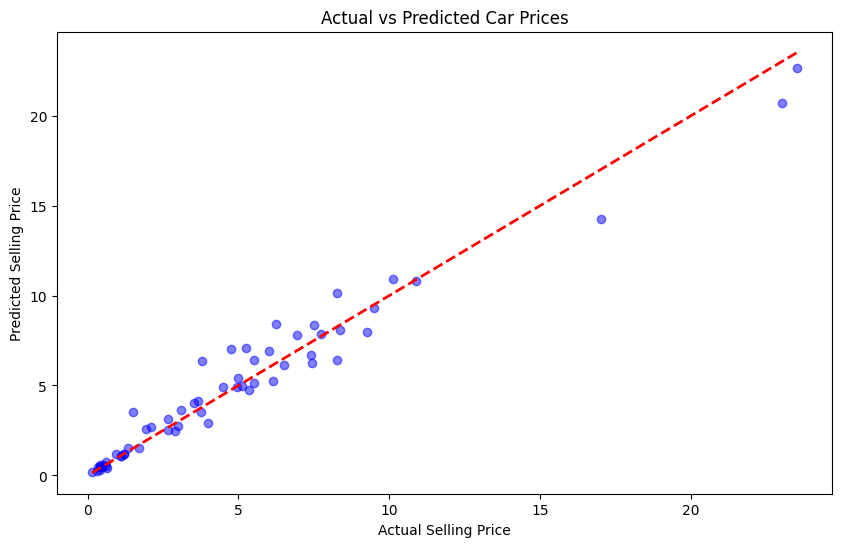

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()